[dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) from UCI repo

In [81]:
import pandas as pd
import numpy as np
from scipy.io import arff
import warnings
warnings.filterwarnings(action='ignore')
# 데이터 전처리
from sklearn.model_selection import train_test_split

# 모델 패키지
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 모델 평가
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rc('font', family='applegothic')

In [420]:
data = pd.read_csv("/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/wine+quality/winequality-red.csv",sep=';')

# arff dataset load
file_path = '/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/bank-additional-ful-nominal.arff'

try:
    data, meta_data = arff.loadarff(file_path)
    data = pd.DataFrame(data)
    for col in data.select_dtypes(['object']).columns: # 2진수 decode 필수
        data[col] = data[col].str.decode('utf-8')

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(e)

In [421]:
print("data 갯수 :\t",len(data))
print("feature 갯수 :\t", len(data.columns))
data.head()

data 갯수 :	 1599
feature 갯수 :	 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [422]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [423]:
# for heart disease data
# wine quality score for 0 to 10
print(data['quality'].value_counts())

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [424]:
# 데이터 전처리
data_modi = data.copy()
data_modi.loc[data['quality'] <= 6,'quality'] = 0
data_modi.loc[data['quality'] > 6,'quality'] = 1


target = data_modi['quality']
print(target.value_counts())

quality
0    1382
1     217
Name: count, dtype: int64


<Axes: xlabel='fixed acidity', ylabel='volatile acidity'>

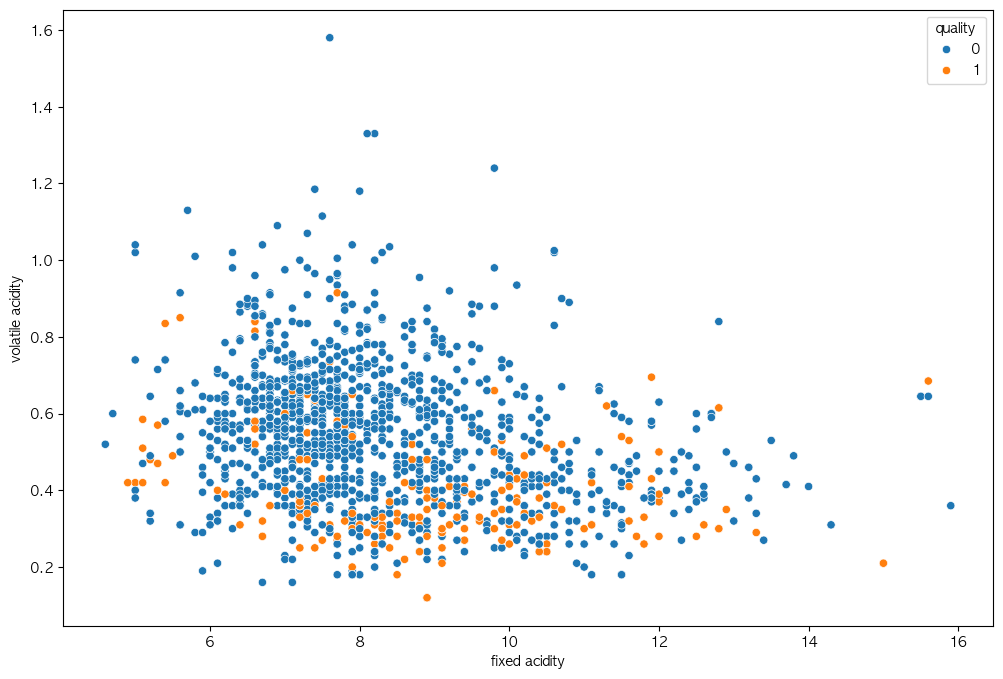

In [425]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='fixed acidity', y='volatile acidity', hue='quality', data=data_modi)

In [ ]:
for col in data_modi:
    sns.distplot(data_modi.loc[data[col].notnull(), col])
    plt.title(col)
    plt.show()

quality
0    1382
1     217
Name: count, dtype: int64


<Axes: title={'center': 'class distribution'}, xlabel='count', ylabel='quality'>

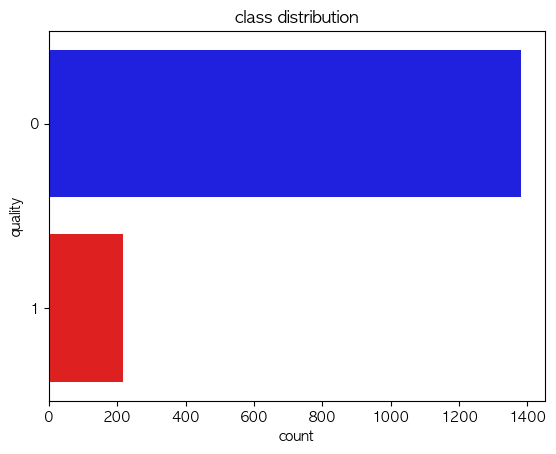

In [89]:
print(target.value_counts())
plt.title("class distribution")
sns.countplot(y=data_modi['quality'], data=data_modi, palette=['blue','red'])

# borderline smote 기법을 이용한 Oversampling

In [90]:
from imblearn.over_sampling import BorderlineSMOTE, SMOTE


bsm = BorderlineSMOTE(random_state=42, kind="borderline-1")

In [ ]:
x = data[data.columns.difference(['quality'])]
y = data['quality']

#over_sampled_x , over_sampled_y = bsm.fit_resample(X=x, y=y)

<Axes: xlabel='fixed acidity', ylabel='volatile acidity'>

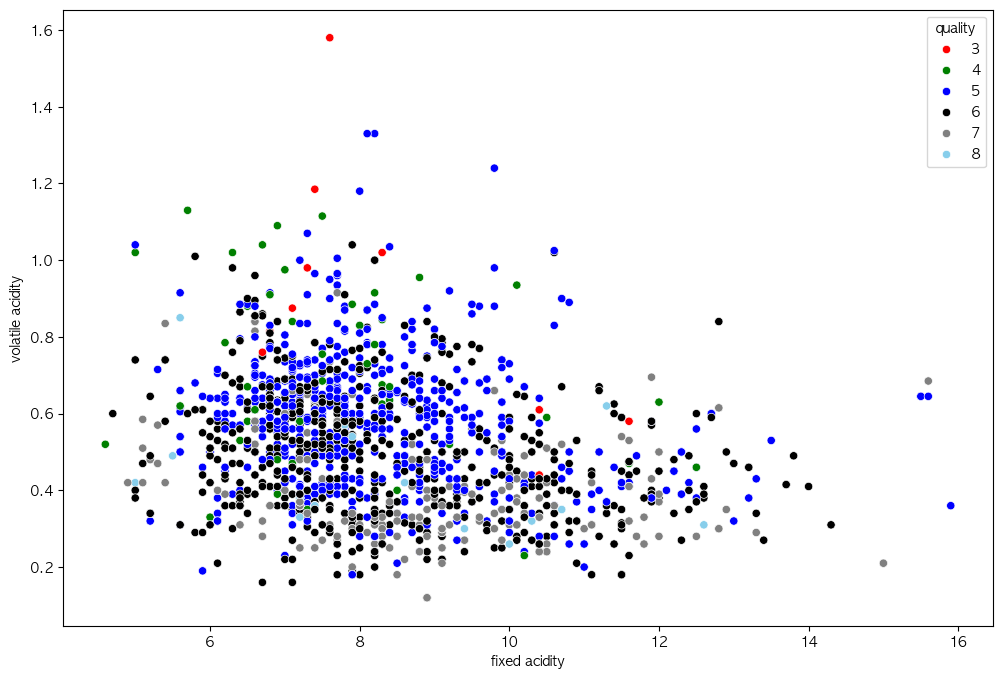

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='fixed acidity', y='volatile acidity', hue=y, data=x)

In [311]:
# # Unused because Borderline SMOTE is any longer being used

# x_train, x_test, y_train, y_test = train_test_split(over_sampled_x,over_sampled_y, test_size=0.2, random_state=42)
# len(x_test)

In [312]:
y_test.value_counts()

quality
0    160
Name: count, dtype: int64

In [335]:
# 명목형 변수 : anaemia diabetes high_blood_pressure serum_creatinine sex smoking - 0 or 1
# time : follow-up perioud
x

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,9.4,0.076,0.00,0.99780,7.4,11.0,3.51,1.9,0.56,34.0,0.700
1,9.8,0.098,0.00,0.99680,7.8,25.0,3.20,2.6,0.68,67.0,0.880
2,9.8,0.092,0.04,0.99700,7.8,15.0,3.26,2.3,0.65,54.0,0.760
3,9.8,0.075,0.56,0.99800,11.2,17.0,3.16,1.9,0.58,60.0,0.280
4,9.4,0.076,0.00,0.99780,7.4,11.0,3.51,1.9,0.56,34.0,0.700
...,...,...,...,...,...,...,...,...,...,...,...
1594,10.5,0.090,0.08,0.99490,6.2,32.0,3.45,2.0,0.58,44.0,0.600
1595,11.2,0.062,0.10,0.99512,5.9,39.0,3.52,2.2,0.76,51.0,0.550
1596,11.0,0.076,0.13,0.99574,6.3,29.0,3.42,2.3,0.75,40.0,0.510
1597,10.2,0.075,0.12,0.99547,5.9,32.0,3.57,2.0,0.71,44.0,0.645


In [336]:
y

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64

In [426]:
# To Avoid modifying downstream code, Just assign original x, y  to over_sample_x(y) variable
over_sampled_x = x
over_sampled_y = y

In [427]:
over_sampled_y[over_sampled_y > 6]

7       7
8       7
16      7
37      7
62      7
       ..
1541    7
1544    7
1549    8
1555    7
1584    7
Name: quality, Length: 217, dtype: int64

In [428]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

over_sampled_y[over_sampled_y <= 6] = 0
over_sampled_y[over_sampled_y > 6] = 1

In [441]:
over_sampled_y.value_counts()

quality
0    1382
1     217
Name: count, dtype: int64

In [445]:
x_train, x_test, y_train, y_test = train_test_split(over_sampled_x ,over_sampled_y, test_size=0.4, random_state=42)

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_test_sc = pd.DataFrame(x_test_sc,columns=x.columns)
x_train_sc = pd.DataFrame(x_train_sc,columns=x.columns)

In [446]:
y_test.value_counts()

quality
0    551
1     89
Name: count, dtype: int64

# PCA
- std 가 큰 변수에 영향을 받는다 → scaling

In [447]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(x_train_sc)

PCA_pred_train = pca.transform(x_train_sc)
result = pca.transform(x_test_sc)
print(pca.explained_variance_ratio_)
result =pd.DataFrame(result, columns=['feature1', 'feature2'])

[0.27696168 0.17424903]


In [448]:
result

,feature1,feature2
0,-0.198409,0.607079
1,-1.007975,1.403884
2,1.826659,0.668110
3,0.233911,1.172349
4,-1.312304,-0.583765
...,...,...
635,-0.671588,1.339965
636,1.352344,-0.328104
637,0.586281,2.344993
638,-1.189345,-0.266453


In [449]:
y_train.value_counts()

quality
0    831
1    128
Name: count, dtype: int64

In [450]:
y_test.value_counts()

quality
0    551
1     89
Name: count, dtype: int64

In [451]:
y_test_reset_index = y_test.reset_index(drop=True)
y_test_reset_index

0      0
1      0
2      0
3      0
4      0
      ..
635    0
636    0
637    0
638    0
639    0
Name: quality, Length: 640, dtype: int64

In [452]:
result['label'] = y_test_reset_index
result

,feature1,feature2,label
0,-0.198409,0.607079,0
1,-1.007975,1.403884,0
2,1.826659,0.668110,0
3,0.233911,1.172349,0
4,-1.312304,-0.583765,0
...,...,...,...
635,-0.671588,1.339965,0
636,1.352344,-0.328104,0
637,0.586281,2.344993,0
638,-1.189345,-0.266453,0


In [453]:
result

,feature1,feature2,label
0,-0.198409,0.607079,0
1,-1.007975,1.403884,0
2,1.826659,0.668110,0
3,0.233911,1.172349,0
4,-1.312304,-0.583765,0
...,...,...,...
635,-0.671588,1.339965,0
636,1.352344,-0.328104,0
637,0.586281,2.344993,0
638,-1.189345,-0.266453,0


In [454]:
result['label'].unique()

array([0, 1])

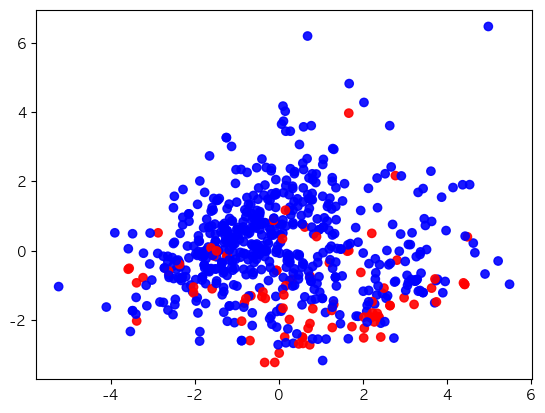

In [455]:
color_map = {0:'blue', 1:'red'}
colors = result['label'].map(color_map)
plt.scatter(x=result['feature1'], y=result['feature2'], c = colors, alpha=0.9)

In [456]:
x_test_sc

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,-0.784073,0.602045,-0.973967,0.186586,-0.343131,-0.187528,-0.497958,-0.043372,0.003466,-0.012913,0.170482
1,-0.877607,-0.106672,-0.514078,-0.408911,-0.283518,0.488923,0.490605,-0.662116,-1.028182,1.716470,-0.170897
2,-0.503468,0.447013,-0.258584,1.973075,1.445252,0.102380,-0.234341,0.094127,1.837508,-0.383495,0.796342
3,-0.597003,-0.195262,0.201305,0.673810,0.133771,1.551919,0.095180,-0.215245,-0.684299,0.357669,-0.398483
4,0.151275,-0.217410,-0.156387,-1.058543,-0.939259,0.199016,0.490605,-0.593366,-0.340416,-0.383495,-0.398483
...,...,...,...,...,...,...,...,...,...,...,...
635,-0.877607,-0.128820,-0.411881,-0.300638,-0.283518,-0.090892,0.095180,-0.318369,-0.684299,1.809116,0.170482
636,-0.971142,1.864448,1.121082,0.403130,0.431835,-0.960616,-0.300245,-0.455868,-0.283103,-0.661432,-0.000208
637,-1.251746,0.380571,-0.616276,0.598020,-0.462356,1.262011,-1.157000,0.781620,-0.455044,1.469416,-0.682965
638,-0.877607,0.624192,-1.280559,-0.116576,-0.998871,-0.960616,0.424701,-0.318369,0.175408,-0.939369,0.227378


              precision    recall  f1-score   support

           0      0.866     0.906     0.886       551
           1      0.188     0.135     0.157        89

    accuracy                          0.798       640
   macro avg      0.527     0.520     0.521       640
weighted avg      0.772     0.798     0.784       640



<Axes: >

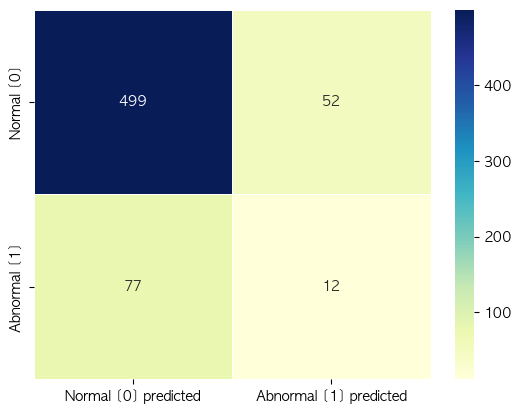

In [457]:
# 재구성 기반은 이상치는 다시 복구가 안될 것이다 라는 전제

# x_train 을 통해서 x_proj 를 계산, 이후에 threshold 설정
x_proj = pca.inverse_transform(pca.transform(x_train_sc))
recon_error = ( (x_train_sc - x_proj) **2 ).sum(axis=1)
recon_error = pd.DataFrame(recon_error,columns=['error']).sort_values(by='error',ascending=False)
thre = np.percentile(recon_error, 90)

x_proj = pca.inverse_transform(pca.transform(x_test_sc))
recon_error = ( (x_test_sc - x_proj) **2 ).sum(axis=1)
pred_pca = (recon_error >= thre).astype(int)

print(classification_report(y_test, pred_pca, digits=3))

cm = confusion_matrix(y_test, pred_pca)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', algorithm='auto', metric='minkowski')
knn.fit(x_train_sc, y_train)

KNeighborsClassifier()

In [459]:
knn_pred_train = knn.predict(x_train_sc)
knn_pred_test = knn.predict(x_test_sc)

print(metrics.accuracy_score(y_train, knn_pred_train))
print(metrics.accuracy_score(y_test, knn_pred_test))

print(classification_report(y_test, knn_pred_test, digits=3))

0.8978102189781022
0.8640625
              precision    recall  f1-score   support

           0      0.903     0.944     0.923       551
           1      0.516     0.371     0.431        89

    accuracy                          0.864       640
   macro avg      0.709     0.657     0.677       640
weighted avg      0.849     0.864     0.854       640



[[520  31]
 [ 56  33]]


<Axes: >

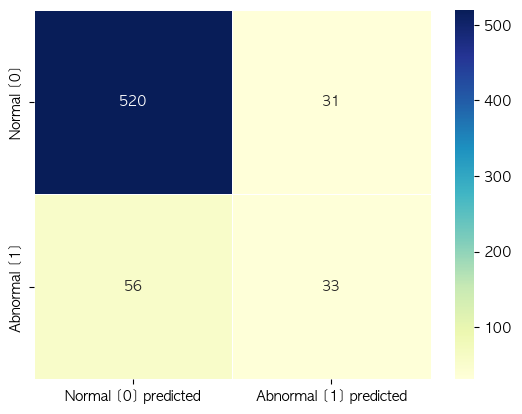

In [460]:
cm = confusion_matrix(y_test, knn_pred_test)

# col : 모델 예측 
# raw : 실제
print(cm)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# KMeans

In [461]:
ssd = []
for num in range(2, 11):
    km = KMeans(n_clusters=num, init='k-means++', random_state=42, n_init=10)
    km.fit(x_train_sc)
    ssd.append(km.inertia_)

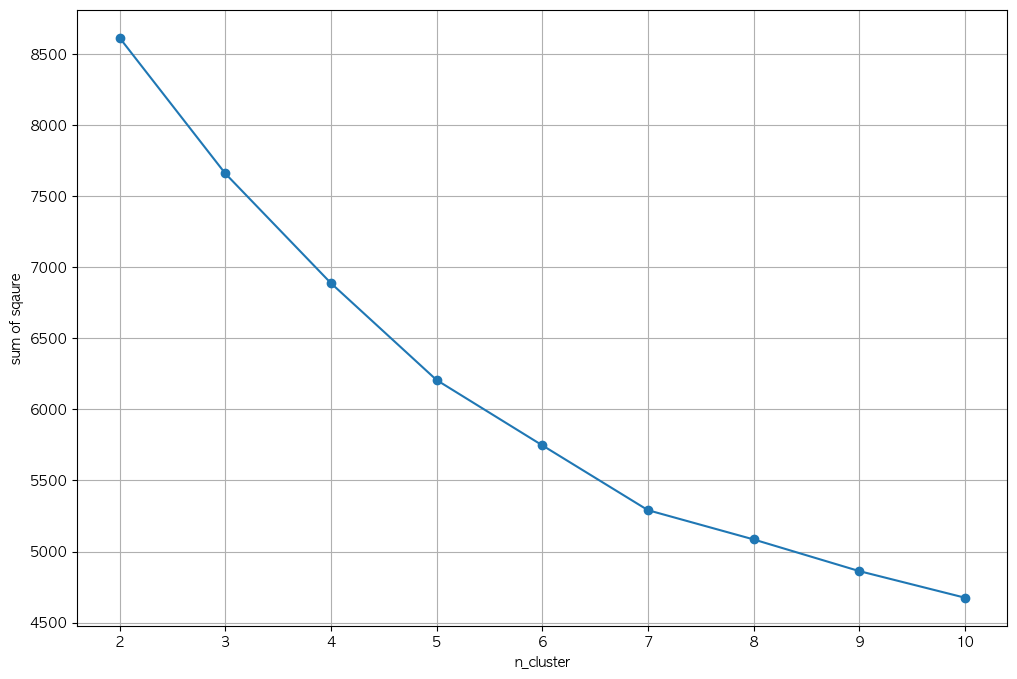

In [462]:
plt.figure(figsize=(12,8))
plt.plot(range(2,11), ssd, marker='o')
plt.xlabel('n_cluster')
plt.ylabel('sum of sqaure')
plt.xticks(range(2,11))
plt.grid()
plt.show()

In [ ]:
km = KMeans(n_clusters=5)
km.fit(x_train)

KMeans(n_clusters=5)

In [464]:
def distance_from_center(input_data:pd.DataFrame, predict:pd.DataFrame, y):
    center = km.cluster_centers_[predict]
    dist = ((center-input_data)**2).sum(axis=1) # center 와 input_data 빼고 제곱하고 
    return np.round(dist, 3)

In [465]:
y_pred_train = km.predict(x_train)
dist_train = distance_from_center(x_train, y_pred_train, y_test)

km_x_train = x_train.copy()
km_x_train.loc[:,'pred'] = y_pred_train # 예측 군집 할당
km_x_train.loc[:, 'dist'] = dist_train # 군집 중심과의 거리

y_pred_test = km.predict(x_test)
dist_test = distance_from_center(x_test, y_pred_test, y_test)

km_x_test = x_test.copy()
km_x_test.loc[:,'dist'] = dist_test
km_x_test.loc[:,'pred'] = y_pred_test

In [466]:
# 24개 test data 에 대해 3개 이상치 데이터로 선정
#outlier_idx = list(x_test.sort_values('dist',ascending=False).head(10).index)

# 2nd way, set the threshold
# threshold = np.percentile(x_test['dist'], 90)

threshold = np.percentile(km_x_train['dist'], 90)
print(threshold)

out_lier = km_x_test[km_x_test['dist'] > threshold]

232.993


In [467]:
out_lier.index

Index([ 247,   23,   32,  184, 1054,  411,  526,  649,  240,  926,  109,  306,
       1389,  678,  905,  711, 1079,  353,  614,   78, 1167,  584,   15,  982,
        634,  332, 1529,  425,  163, 1244,  192, 1175, 1295,  354,  705, 1055,
       1203, 1435,  111, 1358, 1188,  620, 1231, 1597, 1225,  651,  188,  360,
        497, 1409,  925,  906, 1198, 1235,  591,  819, 1296,  561, 1178,  195,
        578,  721, 1182,  164,  672, 1407,  693],
      dtype='int64')

In [468]:
y_pred_test = pd.DataFrame(y_pred_test, index=x_test.index)
y_pred_test.loc[out_lier.index] = 1
y_pred_test.loc[out_lier.index]

,0
247,1
23,1
32,1
184,1
1054,1
...,...
1182,1
164,1
672,1
1407,1


In [469]:
not_out_lier_idx= ~y_pred_test.index.isin(out_lier.index)
y_pred_test.loc[not_out_lier_idx] = 0

In [470]:
print(len(y_pred_test))
print(len(out_lier.index))
print(not_out_lier_idx.sum())

640
67
573


              precision    recall  f1-score   support

           0       0.89      0.85      0.87       573
           1       0.06      0.07      0.06        67

    accuracy                           0.77       640
   macro avg       0.47      0.46      0.47       640
weighted avg       0.80      0.77      0.79       640



<Axes: >

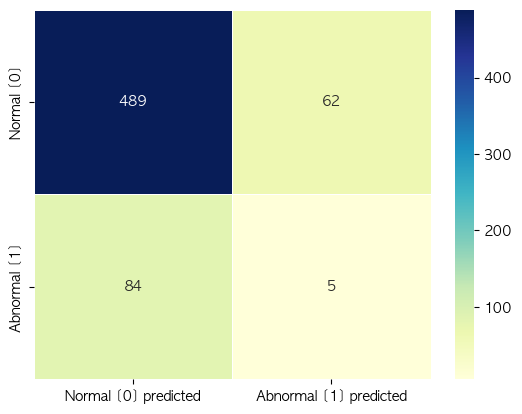

In [471]:
print(classification_report(y_pred_test, y_test))

# dist 가 threshold 보다 큰 outlier 데이터에 대한
# model predict 결과와
# 실제 y_test 
con_mat = confusion_matrix(y_true=y_test, y_pred=y_pred_test)


sns.heatmap(pd.DataFrame(con_mat, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# GMM

- bic 를 통해 모델이 데이터를 얼마나 설명하는가를 판단
- covariance type 을 통해서 공분산 행렬의 형태를 가정 → 이를 통해, mixture 하는 가우시안 분포들이 어떻게 생겼는가를 가정
     - spherical : 모든 공분산이 같은 모양 같은 크기
     - diagonal : 공분산행렬이 대각행렬만 존재, 클러스터의 크기가 다를 수 있음
     - tied : 모양 크기 방향이 같지면 타원형일 수 있음
     - full : 자유자재

In [ ]:
from sklearn.mixture import GaussianMixture
best_bic = np.inf
bic = []
cov_type = ["spherical", "diag", "tied", "full"]
n_components_range = range(2,11)

for type in cov_type:
    for n_components in n_components_range:
        mog = GaussianMixture(
            n_components=n_components, covariance_type=type
        )
        mog.fit(x_train_sc)
        bic.append(mog.bic(x_train_sc))
        if bic[-1] < best_bic:
            best_bic = bic[-1]
            best_mog = mog

In [584]:
print(best_mog.covariance_type)
print(best_mog.n_components)

full
3


In [585]:
mog_range = best_mog.n_components

In [586]:
range(mog_range)
range_map = {k : 0 for k in range(mog_range-1)}
range_map[mog_range-1] = 1
range_map

{0: 0, 1: 0, 2: 1}

In [587]:
mog_test_pred = best_mog.predict(x_test_sc)
mog_test_pred = pd.DataFrame(mog_test_pred)
mog_test_pred = mog_test_pred.replace(range_map)

mog_train_pred = best_mog.predict(x_train_sc)
mog_train_pred = pd.DataFrame(mog_train_pred)
mog_train_pred = mog_train_pred.replace(range_map)

In [588]:
mog_train_pred.value_counts()

0
0    762
1    197
Name: count, dtype: int64

In [589]:
mog_metric = y_train.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_train_pred

# recall
print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1], '\n')

print(len(mog_metric[(mog_metric['quality'] ==0) & (mog_metric['mog_pred'] ==0)]))
print("--")
print(mog_metric['quality'].value_counts()[0])

34
--
128 

668
--
831


In [590]:
mog_metric = y_test.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_test_pred

print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1])

18
--
89


              precision    recall  f1-score   support

           0      0.863     0.815     0.838       551
           1      0.150     0.202     0.172        89

    accuracy                          0.730       640
   macro avg      0.507     0.509     0.505       640
weighted avg      0.764     0.730     0.746       640



Text(0.5, 23.52222222222222, 'Predicted')

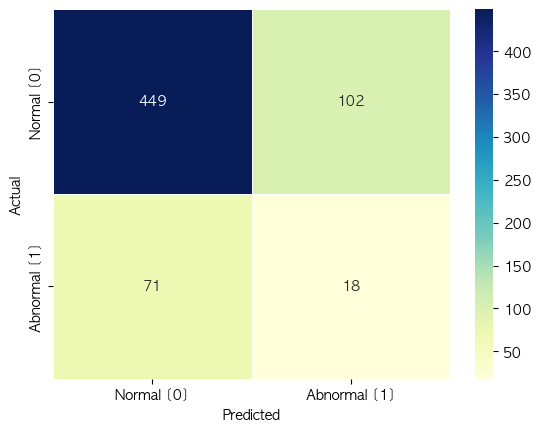

In [591]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print(classification_report(y_true=mog_metric['quality'], y_pred=mog_metric['mog_pred'], digits=3))

con_mat = confusion_matrix(mog_metric['quality'], mog_metric['mog_pred'])

sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# IForest

In [592]:
from sklearn.ensemble import IsolationForest

In [667]:
isol = IsolationForest(contamination=0.1, random_state=42)
isol.fit(X=x_train, y=y_train)

IsolationForest(contamination=0.1, random_state=42)

              precision    recall  f1-score   support

           0       0.87      0.90      0.88       551
           1       0.20      0.16      0.18        89

    accuracy                           0.80       640
   macro avg       0.53      0.53      0.53       640
weighted avg       0.78      0.80      0.78       640



Text(0.5, 23.52222222222222, 'Predicted')

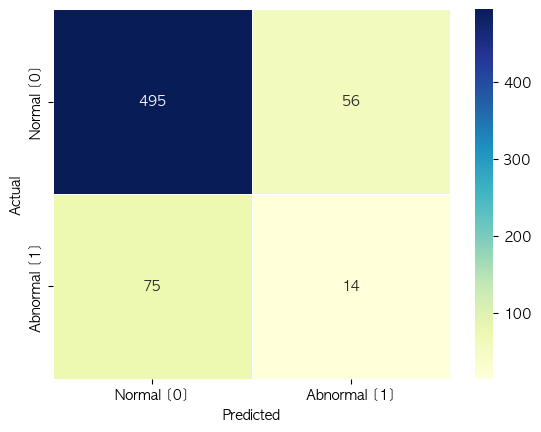

In [668]:
# -1 : anomaly
# 1 : normal
isol_pred_test = isol.predict(x_test)
isol_pred_test = pd.DataFrame(isol_pred_test)
isol_pred_test = isol_pred_test.replace({1:0, -1:1})

print(classification_report(y_true = y_test, y_pred = isol_pred_test))

con_mat = confusion_matrix(y_test, isol_pred_test)
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# LoF

In [595]:
from sklearn.neighbors import LocalOutlierFactor

              precision    recall  f1-score   support

           0       0.88      0.87      0.87      1382
           1       0.23      0.25      0.24       217

    accuracy                           0.78      1599
   macro avg       0.55      0.56      0.55      1599
weighted avg       0.79      0.78      0.79      1599



Text(0.5, 23.52222222222222, 'Predicted')

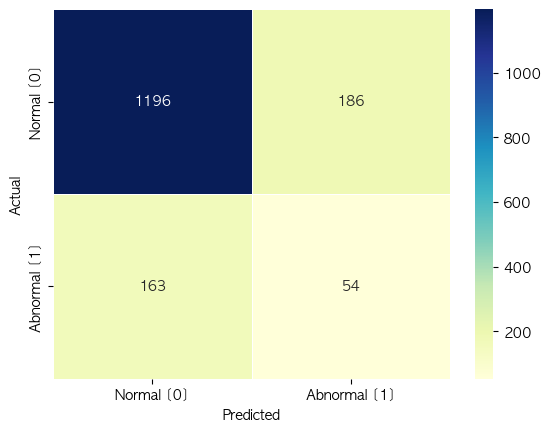

In [669]:
lof = LocalOutlierFactor(novelty=False, n_neighbors=20, algorithm='auto',contamination=0.15)

result = lof.fit_predict(X=over_sampled_x, y=over_sampled_y) # y doesnt use in fitting procedure

result = pd.DataFrame(result)
result = result.replace({1:0, -1:1})

print(classification_report(y_true = over_sampled_y, y_pred = result))

con_mat = confusion_matrix(y_true= over_sampled_y, y_pred = result)
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Auto Encoder

In [679]:
import torch
import torch.nn as nn
import torch.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


class AutoEncoder(nn.Module):
    def __init__(self, input_dim, **kwargs):
        super(AutoEncoder,self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, input_dim)
        )
    def forward(self, x):
        x = self.encoder(x)
        out = self.decoder(x)
        return out

class WineDataset(Dataset):
    def __init__(self, input:pd.DataFrame, target:pd.DataFrame):
        self.input = torch.tensor(input.values, dtype=torch.float32)
        self.target = torch.tensor(target.values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.input)
    def __getitem__(self, index):
        return self.input[index], self.target[index]

In [680]:
model_config={
    "input_dim" : len(x_train_sc.columns),
    "batch_size" : 16,
    "lr" : 1e-3,
    "loss" : nn.MSELoss(),
    "epoch" : 250
}

train_dataset = WineDataset(x_train_sc, y_train)
test_dataset = WineDataset(x_test_sc, y_test)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

model = AutoEncoder(input_dim=model_config['input_dim'])

criterion = model_config["loss"]
optimizer = optim.Adam(model.parameters(), lr=model_config["lr"])

In [681]:
device = torch.device('cpu')

train_losses = []
test_losses = []

for epoch in range(model_config['epoch']):
    model.train()
    train_loss = 0
    test_loss = 0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    train_epoch_loss = train_loss / len(train_dataset)
    train_losses.append(train_epoch_loss)
    
    with torch.no_grad():    
        model.eval()
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            test_loss += loss.item() * inputs.size(0)
        test_epoch_loss = test_loss / len(test_dataset)
        test_losses.append(test_epoch_loss)
        
    print(f"Epoch [{epoch+1}/{model_config['epoch']}] completed. [Train] Average Loss: {train_epoch_loss:.4f} , [Test] Average Loss : {test_epoch_loss:.4f}")


Epoch [1/250] completed. [Train] Average Loss: 1.0253 , [Test] Average Loss : 1.0598
Epoch [2/250] completed. [Train] Average Loss: 0.9872 , [Test] Average Loss : 0.9593
Epoch [3/250] completed. [Train] Average Loss: 0.8180 , [Test] Average Loss : 0.7777
Epoch [4/250] completed. [Train] Average Loss: 0.7424 , [Test] Average Loss : 0.7450
Epoch [5/250] completed. [Train] Average Loss: 0.7220 , [Test] Average Loss : 0.7328
Epoch [6/250] completed. [Train] Average Loss: 0.7108 , [Test] Average Loss : 0.7218
Epoch [7/250] completed. [Train] Average Loss: 0.7016 , [Test] Average Loss : 0.7150
Epoch [8/250] completed. [Train] Average Loss: 0.6956 , [Test] Average Loss : 0.7117
Epoch [9/250] completed. [Train] Average Loss: 0.6907 , [Test] Average Loss : 0.7089
Epoch [10/250] completed. [Train] Average Loss: 0.6869 , [Test] Average Loss : 0.7058
Epoch [11/250] completed. [Train] Average Loss: 0.6821 , [Test] Average Loss : 0.7016
Epoch [12/250] completed. [Train] Average Loss: 0.6776 , [Test]

In [682]:
from tqdm import tqdm

# recent value 
# \*모든 클래스의 조상인 object 클래스
class AverageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.avg = 0
        self.val = 0
        self.sum = 0
        self.count = 0
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def compute_mse(pred,target):
    pass

In [683]:
def train(model_config, dataset, criterion):
    device = torch.device('cpu')
    train_loader = DataLoader(dataset=dataset[0],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    test_loader = DataLoader(dataset=dataset[1],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    
    model = AutoEncoder(input_dim=model_config['input_dim'])
    model.to(device)
    
    optimizer=optim.Adam(model.parameters(), lr=model_config['lr'])
    
    train_loss, test_loss = AverageMeter(), AverageMeter()
    train_loss_list, test_loss_list = [], []
    best_loss = 0
    
    for epoch in range(1, model_config['epoch']):
        model.train()
        train_bar = tqdm(train_loader) #visualize repeatation part
        train_loss.reset()
        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            pred = model(inputs)
            loss = criterion(pred, inputs) # audoencoder calculate loss using inputs & pred
            loss.backward()
            optimizer.step()
            train_loss.update(loss.item(), model_config['batch_size'])
            train_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [train] Loss : {train_loss.avg:.6f}")
        train_loss_list.append(train_loss.avg)
    
        test_bar = tqdm(test_loader)
        test_loss.reset()
    
        for inputs, targets in test_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            model.eval()
            with torch.no_grad():
                pred = model(inputs)
                loss = criterion(pred, inputs)
                test_loss.update(loss.item(), model_config['batch_size'])
                test_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [test] Loss : {test_loss.avg:.6f}")
        test_loss_list.append(test_loss.avg)
    return train_loss_list, test_loss_list

In [684]:
train_loss_list, test_loss_list = train(model_config, [train_dataset, test_dataset], criterion=criterion)

249/250 [test] Loss : 0.521148: 100%|██████████| 40/40 [00:00<00:00, 944.07it/s]


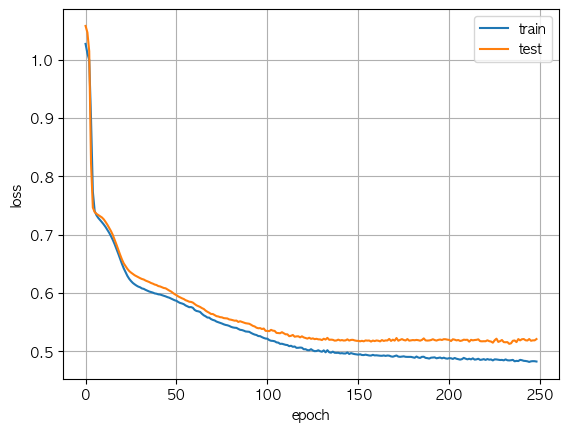

In [685]:
plt.plot(train_loss_list, label='train')
plt.plot(test_loss_list, label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid()

In [686]:
model.eval()

ae_train_pred = model(torch.tensor(x_train_sc.values, dtype=torch.float32))

train_mse = np.mean(np.power(ae_train_pred.detach().numpy() - x_train_sc, 2), axis=1)
threshold = np.percentile( sorted(train_mse), 90)

ae_test_pred = model(torch.tensor(x_test_sc.values, dtype=torch.float32))
test_mse = np.mean(np.power(ae_test_pred.detach().numpy() - x_test_sc, 2), axis=1)


              precision    recall  f1-score   support

           0       0.85      0.89      0.87       551
           1       0.07      0.06      0.06        89

    accuracy                           0.77       640
   macro avg       0.46      0.47      0.47       640
weighted avg       0.75      0.77      0.76       640



<Axes: >

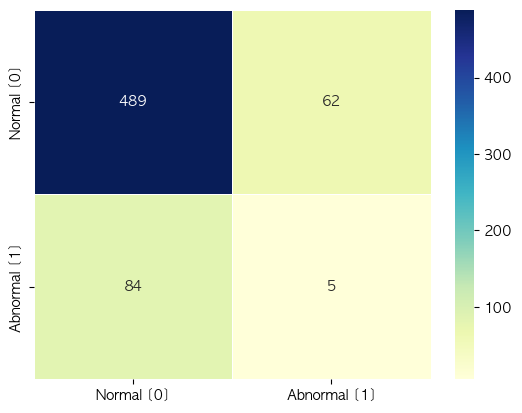

In [687]:
outlier_idx = test_mse[test_mse > threshold].index
ae_y_pred = y_test.copy()
ae_y_pred = pd.DataFrame(ae_y_pred)
ae_y_pred['pred'] = 0
ae_y_pred.loc[out_lier.index, 'pred'] = 1

print(classification_report(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred']))

con_mat = confusion_matrix(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred'])
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# My pick : One class SVM

In [691]:
print(y.value_counts())

x_train, x_test, y_train, y_test = train_test_split(over_sampled_x, over_sampled_y , test_size=0.4, random_state=42)

quality
0    1382
1     217
Name: count, dtype: int64


In [692]:
from sklearn.svm import OneClassSVM

sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

oc_svm = OneClassSVM(kernel='rbf', nu=0.2)
oc_svm.fit(x_train_sc)

y_pred_svm = oc_svm.predict(x_test_sc) # 정상 1, 이상치 -1


In [693]:
y_pred_svm[y_pred_svm == 1] = 0
y_pred_svm[y_pred_svm == -1] = 1
y_pred_svm

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,

              precision    recall  f1-score   support

           0      0.864     0.759     0.808       551
           1      0.147     0.258     0.188        89

    accuracy                          0.689       640
   macro avg      0.506     0.509     0.498       640
weighted avg      0.764     0.689     0.722       640



Text(50.722222222222214, 0.5, 'actual')

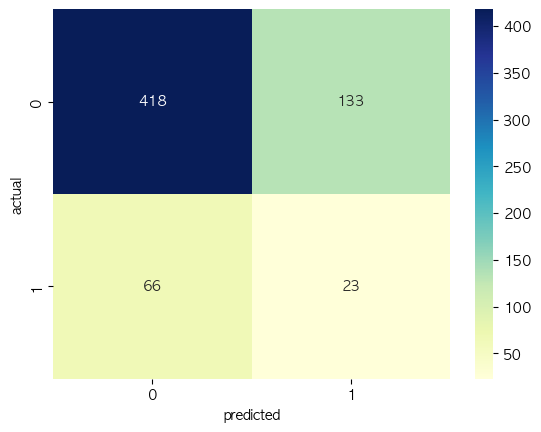

In [694]:
print(classification_report(y_true = y_test, y_pred=y_pred_svm, digits=3))

con_mat = confusion_matrix(y_true = y_test, y_pred=y_pred_svm)

sns.heatmap(con_mat, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('predicted')
plt.ylabel('actual')

In [695]:
con_mat # row : actual , col : predicted

array([[418, 133],
       [ 66,  23]])

# KNN's develop
- weighted knn

In [696]:
y_test.value_counts()

quality
0    551
1     89
Name: count, dtype: int64

In [697]:
w_knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
w_knn.fit(x_train_sc, y_train)

y_pred_wknn = w_knn.predict(x_test_sc)

In [698]:
print(classification_report(y_true=y_test, y_pred=y_pred_wknn))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       551
           1       0.61      0.52      0.56        89

    accuracy                           0.89       640
   macro avg       0.76      0.73      0.75       640
weighted avg       0.88      0.89      0.88       640



Text(50.722222222222214, 0.5, 'actual')

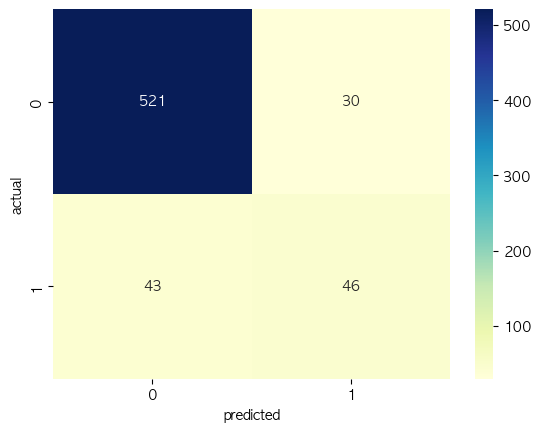

In [699]:
con_mat = confusion_matrix(y_true = y_test, y_pred=y_pred_wknn)

sns.heatmap(con_mat, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('predicted')
plt.ylabel('actual')

# ABOD (Angle Based Outlier Detection)
- normal 데이터는 군집내 다른 두점을 연결해 만들어진 각도 $\angle APB$ 의 분산이 클 것임 (서로서로 보여있으니깐)
- normal 군집에서 떨어진 outlier 는 비교적 각도의 분산이 작을 것임

In [700]:
from pyod.models.abod import ABOD

In [701]:
detector = ABOD(contamination=0.2, n_neighbors=5, method='fast')

In [702]:
detector.fit(x_train)

ABOD(contamination=0.2, method='fast', n_neighbors=5)

In [706]:
pred_y_abod = detector.predict(x_test)

In [707]:
print(classification_report(y_test, pred_y_abod))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83       551
           1       0.12      0.16      0.13        89

    accuracy                           0.72       640
   macro avg       0.49      0.48      0.48       640
weighted avg       0.75      0.72      0.73       640



Text(50.722222222222214, 0.5, 'actual')

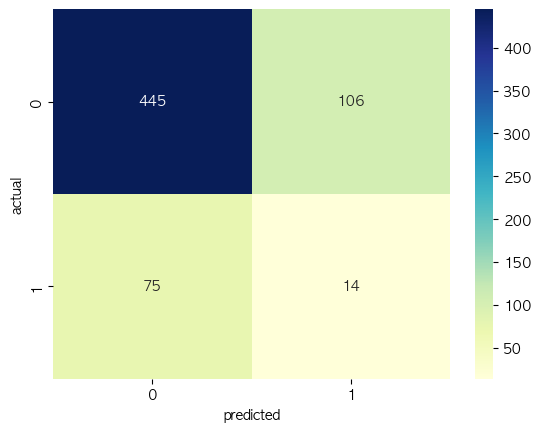

In [708]:
con_mat = confusion_matrix(y_true = y_test, y_pred=pred_y_abod)

sns.heatmap(con_mat, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('predicted')
plt.ylabel('actual')